<a href="https://colab.research.google.com/github/gabrielpferreira15/ia-ciberseguranca/blob/main/notebook3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para Cibersegurança — Aula 3
## Dados e features em segurança: classificação de ataques e clustering (CIC-IDS2017)

**Trio:** `Gabriel Peixoto`  ·  `Arthur Leandro` · `Pedro Pimentel`

> Rodem as células na ordem.

Nesta aula prática vamos trabalhar com **tráfego de rede real** do CIC-IDS2017 e percorrer, de ponta a ponta:
dados → EDA → preparação → **Random Forest** (supervisionado) → feature importance → **K-Means** (não supervisionado) → comparação.

O foco é **entender os dados e as features de segurança** e ver, na prática, a diferença entre classificar ataques (com rótulos) e descobrir grupos (sem rótulos).

## 1. Introdução

O **CIC-IDS2017** (Canadian Institute for Cybersecurity) contém fluxos de rede capturados numa rede de teste com tráfego benigno e vários ataques (DoS, DDoS, PortScan, força bruta, web attacks, etc.).

- **Cada registro é um fluxo de rede** — uma conexão resumida por dezenas de features (duração, nº de pacotes, bytes por segundo, tamanhos de pacote, flags TCP…), extraídas pelo CICFlowMeter.
- **Classificar como benigno ou ataque** é decidir, a partir dessas features, se aquele fluxo é comportamento normal ou malicioso.
- **Por que ML?** As assinaturas tradicionais só pegam ataques conhecidos. Modelos aprendem padrões nas features e generalizam para variações — úteis quando o volume de tráfego é grande demais para regras manuais.

> Não vamos aprofundar teoria: a ideia é **mexer nos dados** e interpretar o que sai.

# Motivação sobre ML-Based Intrusion Detection

---

* Mesmo com diferentes mecanismos de autenticação, firewall, criptografia e segurança de modo geral sendo aplicados em todas as camadas, ataques ainda são possíveis e acontecem.

* Sistemas de detecção de intrusão são o último recurso de segurança
  * Detectam e reportam a ocorrência de ataques e atividades suspeitas quando outros mecanismos de segurança não conseguem impedi-los
  * Tais como outros mecanismos de segurança, são amplamente utilizados
    * Mas costumam apresentar vários problemas e limitações:
      * Dependência de assinaturas e limitação a ataques conhecidos
      * Necessidade de analisar e rotular grandes quantidades de dados
      * Tempos de detecção longos
      * ...

* O uso de **inteligência artificial** pode ajudar em superar esses problemas e limitações

# Sistemas de Detecção de Intrusão

---

* **Second Line of Defense**
* **Last Security Resource**
* **Monitor Networks and Systems**
* **Detect and Report Suspicious Activities**

---

### **Taxonomy**

| Monitoring Environment | Placement Strategy | Operation Mode | Detection Method |
| :--- | :--- | :--- | :--- |
| • Host-based | • Centralized | • Off-line | • Signature-based |
| • Network-based | • Distributed | • Real-time | • Anomaly-based |
| | | | • Hybrid |

# Sistemas de Detecção de Intrusão

---

* **Baseados em assinaturas**
  * Regras de detecção baseadas em atividades maliciosas
  * Precisa-se entender a atividade maliciosa e como ela impacta determinados atributos

* **Baseados em anomalia**
  * Regras de detecção baseadas em desvios do comportamento benigno
  * Precisa-se estabelecer qual o comportamento benigno de determinado sistema ou rede e medir desvios desse comportamento

---

> ➤ **Essas duas estratégias se complementam, pois uma olha para as atividades maliciosas e a outra para as atividades normais.**

## 2. Bibliotecas e configuração

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score, silhouette_score)

sns.set_theme(style='whitegrid')
RANDOM_SEED = 33
np.random.seed(RANDOM_SEED)

## 3. Carregamento dos dados

O dataset completo é pesado (vários GB, ~2,8 milhões de fluxos). Para a aula, baixamos a versão **MachineLearningCVE** (os CSVs já com as features de fluxo + coluna `Label`) e, mais adiante, trabalhamos com uma **amostra** para manter tudo leve.

In [13]:
!pip install -q awscli
!aws s3 cp --no-sign-request --region ca-central-1 "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv" wed2018.csv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 27.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv to ./wed2018.csv


In [14]:
df = pd.read_csv('wed2018.csv', low_memory=False)
df.columns = df.columns.str.strip()

# 2018 usa 'Benign' (B maiúsculo) -> padroniza para 'BENIGN'
df['Label'] = df['Label'].astype(str).str.strip()
df.loc[df['Label'].str.upper() == 'BENIGN', 'Label'] = 'BENIGN'

print('Dimensões:', df.shape)
print('Rótulos:', df['Label'].unique()[:12], '...')
df.head()

Dimensões: (613104, 80)
Rótulos: ['BENIGN' 'Label' 'Infilteration'] ...


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,28/02/2018 08:22:13,94658,6,7,708,3718,387,0,...,20,0,0,0,0,0,0,0,0,BENIGN
1,443,6,28/02/2018 08:22:13,206,2,0,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN
2,445,6,28/02/2018 08:22:15,165505,3,1,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN
3,443,6,28/02/2018 08:22:16,102429,6,7,708,3718,387,0,...,20,0,0,0,0,0,0,0,0,BENIGN
4,443,6,28/02/2018 08:22:16,167,2,0,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN


Vamos olhar os tipos das variáveis e identificar a coluna alvo (`Label`).

In [15]:
print('Coluna alvo: Label ->', df['Label'].unique()[:8], '...')
df.info()

Coluna alvo: Label -> ['BENIGN' 'Label' 'Infilteration'] ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613104 entries, 0 to 613103
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Dst Port           613104 non-null  object
 1   Protocol           613104 non-null  object
 2   Timestamp          613104 non-null  object
 3   Flow Duration      613104 non-null  object
 4   Tot Fwd Pkts       613104 non-null  object
 5   Tot Bwd Pkts       613104 non-null  object
 6   TotLen Fwd Pkts    613104 non-null  object
 7   TotLen Bwd Pkts    613104 non-null  object
 8   Fwd Pkt Len Max    613104 non-null  object
 9   Fwd Pkt Len Min    613104 non-null  object
 10  Fwd Pkt Len Mean   613104 non-null  object
 11  Fwd Pkt Len Std    613104 non-null  object
 12  Bwd Pkt Len Max    613104 non-null  object
 13  Bwd Pkt Len Min    613104 non-null  object
 14  Bwd Pkt Len Mean   613104 non-null  object
 15  Bwd Pkt

### Verificando problemas nos dados
O CIC-IDS2017 tem três problemas conhecidos: **registros duplicados**, **valores NaN** e **valores infinitos** (em features como `Flow Bytes/s`, que dividem por tempo e podem estourar).

In [16]:
print('Duplicatas :', df.duplicated().sum())
print('NaN totais :', int(df.isna().sum().sum()))
inf_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if np.isinf(df[c]).any()]
print('Colunas com valores infinitos:', inf_cols)

Duplicatas : 6121
NaN totais : 4041
Colunas com valores infinitos: []


### Limpeza
Descartamos duplicatas e NaN; para os infinitos, seguimos a abordagem das aulas anteriores — substituir pelo **maior valor finito** da coluna, preservando o registro.

In [17]:
ini = len(df)
df = df.drop_duplicates().dropna().reset_index(drop=True)
print(f'Duplicatas/NaN removidos: {ini - len(df)}  |  restam {len(df)} registros')

for col in df.select_dtypes(include=[np.number]).columns:
    mask_inf = np.isinf(df[col])
    if mask_inf.any():
        df.loc[mask_inf, col] = df.loc[~mask_inf, col].max()
print('Infinitos tratados. Dimensões:', df.shape)

Duplicatas/NaN removidos: 8790  |  restam 604314 registros
Infinitos tratados. Dimensões: (604314, 80)


Padronizamos os rótulos de *web attacks*, que vêm com caracteres estranhos de codificação.

In [18]:
df['Label'] = (df['Label'].str.replace('Web Attack.*Brute Force', 'Web Attack - Brute Force', regex=True)
                            .str.replace('Web Attack.*XSS', 'Web Attack - XSS', regex=True)
                            .str.replace('Web Attack.*Sql Injection', 'Web Attack - Sql Injection', regex=True))
df['Label'].value_counts()

,count
Label,
BENIGN,535865
Infilteration,68448
Label,1


### Amostra de trabalho
Para o notebook rodar rápido em qualquer máquina, tiramos uma **amostra estratificada** (~200 mil fluxos), preservando a proporção original entre classes. Assim mantemos o desbalanceamento realista, mas com custo baixo.

In [19]:
N_ALVO = 200_000
if len(df) > N_ALVO:
    frac = N_ALVO / len(df)
    df = (df.groupby('Label', group_keys=False)
            .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))
            .reset_index(drop=True))
print('Amostra de trabalho:', df.shape)

/tmp/ipykernel_4600/1716381155.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))


Amostra de trabalho: (200001, 80)


## 4. EDA simples

Comecemos pelo essencial: **quanto do tráfego é ataque** e **quais ataques** aparecem.

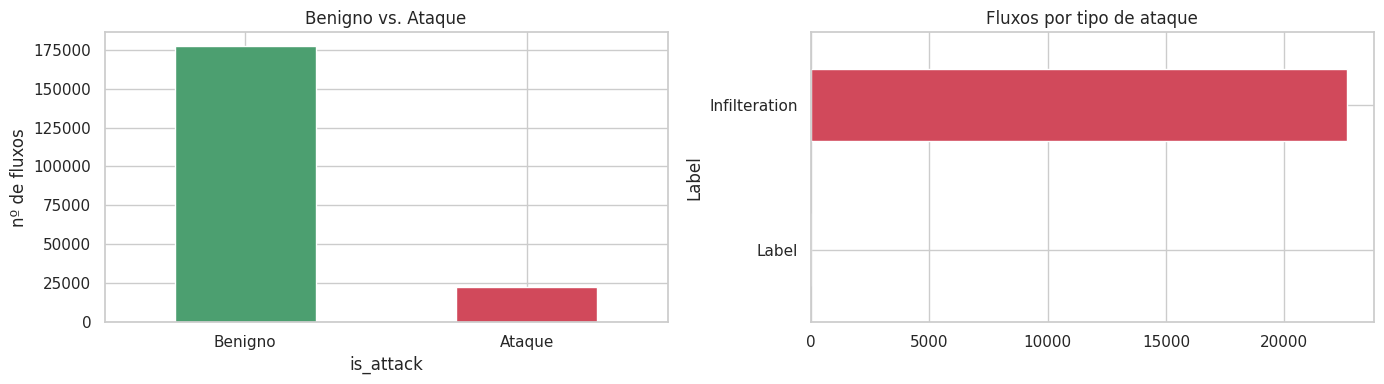

In [20]:
df['is_attack'] = (df['Label'] != 'BENIGN').astype(int)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df['is_attack'].map({0:'Benigno', 1:'Ataque'}).value_counts().plot(
    kind='bar', ax=ax[0], color=['#4C9F70', '#D1495B'])
ax[0].set_title('Benigno vs. Ataque'); ax[0].set_ylabel('nº de fluxos')
ax[0].tick_params(axis='x', rotation=0)

ataques = df[df['Label'] != 'BENIGN']['Label'].value_counts()
ataques.plot(kind='barh', ax=ax[1], color='#D1495B')
ax[1].set_title('Fluxos por tipo de ataque'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

**O que observar:** o tráfego é **fortemente desbalanceado** — a imensa maioria é benigna, e entre os ataques alguns tipos (DoS Hulk, PortScan, DDoS) dominam enquanto outros têm pouquíssimos exemplos. Isso afeta tanto o treino quanto a escolha de métricas mais adiante.

Vamos olhar a escala de algumas features numéricas típicas de fluxo.

In [21]:
cols_desejadas = ['Flow Duration', 'Flow Bytes/s', 'Total Fwd Packets',
                  'Average Packet Size', 'SYN Flag Count']

cols_existentes = [c for c in cols_desejadas if c in df.columns]

if len(cols_existentes) == 0:
    cols_existentes = [
        c for c in df.columns
        if any(term in c for term in ['Duration', 'Pkts', 'Byts', 'Size', 'Flag', 'Pkt'])
    ][:5]

print("Colunas analisadas:", cols_existentes)
df[cols_existentes].describe()

Colunas analisadas: ['Flow Duration']


,Flow Duration
count,200001
unique,83374
top,2
freq,6649


Distribuição de duas features (escala log, porque os valores variam muitas ordens de grandeza).

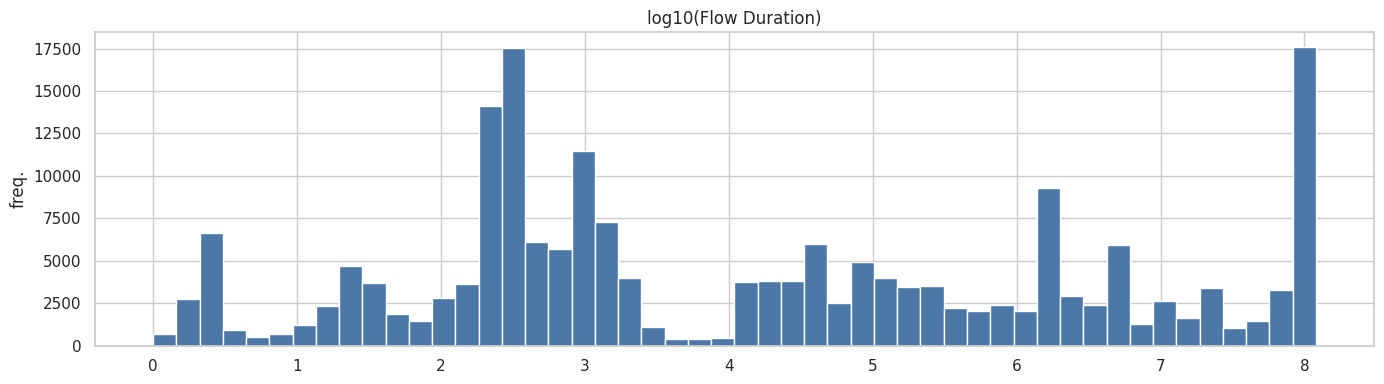

In [22]:
cols_alvo = ['Flow Duration', 'Total Fwd Packets']
cols_para_plot = []

for c in cols_alvo:
    if c in df.columns:
        cols_para_plot.append(c)
    else:
        match = [col for col in df.columns if any(k in col for k in ['Duration', 'Pkts', 'Pkt'])]
        if match:
            cols_para_plot.append(match[0])

cols_para_plot = list(dict.fromkeys(cols_para_plot))[:2]

fig, ax = plt.subplots(1, len(cols_para_plot), figsize=(14, 4))
if len(cols_para_plot) == 1:
    ax = [ax]

for a, col in zip(ax, cols_para_plot):
    s_numeric = pd.to_numeric(df[col], errors='coerce').fillna(0)
    vals = s_numeric.clip(lower=0) + 1
    a.hist(np.log10(vals), bins=50, color='#4C78A8')
    a.set_title(f'log10({col})')
    a.set_ylabel('freq.')

plt.tight_layout()
plt.show()

**O que observar:** distribuições muito assimétricas e de cauda longa — comuns em tráfego de rede. É por isso que, para modelos baseados em distância (K-Means), a **padronização** será importante.

Comparando uma feature entre benigno e alguns ataques (boxplot).

Coluna utilizada para o boxplot: Tot Fwd Pkts


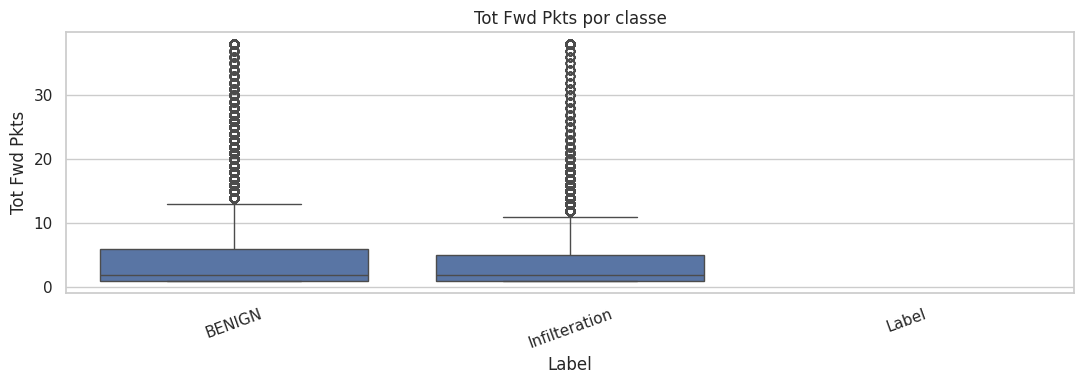

In [23]:
col_fwd = 'Total Fwd Packets'
if col_fwd not in df.columns:
    match = [c for c in df.columns if 'Fwd' in c and ('Pkt' in c or 'Packet' in c)]
    if match:
        col_fwd = match[0]

print(f"Coluna utilizada para o boxplot: {col_fwd}")

top_ataques = df[df['Label'] != 'BENIGN']['Label'].value_counts().head(4).index.tolist()
sub = df[df['Label'].isin(['BENIGN'] + top_ataques)].copy()

sub[col_fwd] = pd.to_numeric(sub[col_fwd], errors='coerce')
sub[col_fwd] = sub[col_fwd].clip(upper=sub[col_fwd].quantile(0.99))

plt.figure(figsize=(11, 4))
sns.boxplot(data=sub, x='Label', y=col_fwd, order=['BENIGN'] + top_ataques)
plt.xticks(rotation=20)
plt.title(f'{col_fwd} por classe')
plt.tight_layout()
plt.show()

**O que observar:** algumas classes de ataque têm distribuição de pacotes bem diferente do tráfego benigno — é exatamente esse tipo de separação que o modelo vai explorar.

Correlação entre um subconjunto de features (para não poluir com 78 colunas).

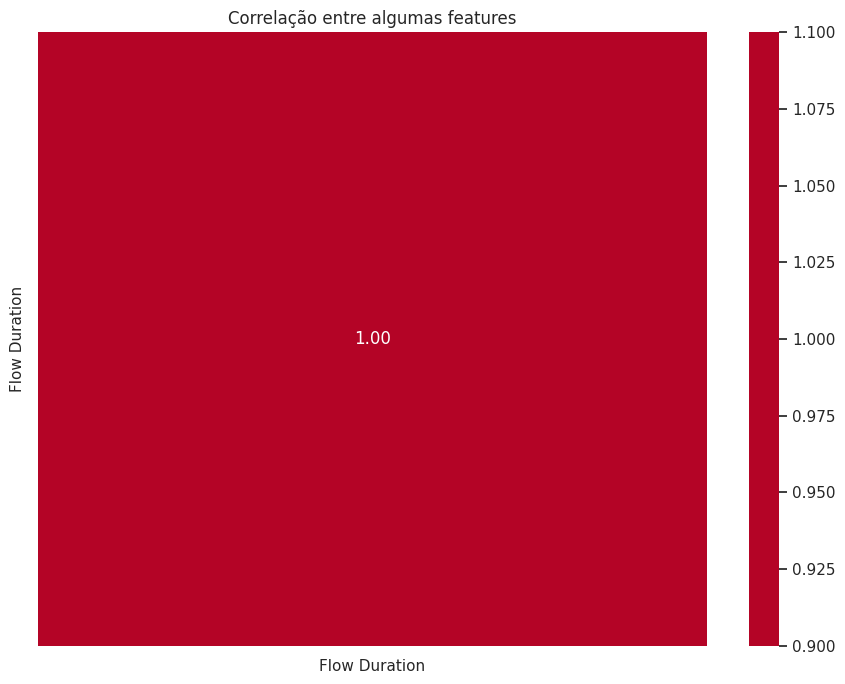

In [24]:
cols_corr = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
             'Flow Bytes/s', 'Flow Packets/s', 'Average Packet Size',
             'Fwd Packet Length Mean', 'Bwd Packet Length Mean']

cols_existentes = [c for c in cols_corr if c in df.columns]

if len(cols_existentes) == 0:
    cols_existentes = [
        c for c in df.columns
        if any(k in c for k in ['Duration', 'Pkts', 'Byts', 'Size', 'Mean', 'Pkt', 'Length'])
    ][:8]

df_corr = df[cols_existentes].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(9, 7))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre algumas features')
plt.tight_layout()
plt.show()

**O que observar:** pares de features muito correlacionados (ex.: contagens e tamanhos de pacote) carregam informação redundante — algo a considerar ao escolher features.

## 5. Preparação dos dados

- **Alvo:** vamos classificar **Benigno (0) vs. Ataque (1)** — um problema binário, claro para começar.
- **Features:** todas as colunas numéricas de fluxo.
- **Data leakage:** fazemos o `train_test_split` **antes** de qualquer ajuste que dependa dos dados (aqui o Random Forest nem precisa de normalização; a padronização entra só no K-Means, ajustada no conjunto certo).

In [25]:
import numpy as np

y = (df['Label'] != 'BENIGN').astype(int)
cols_features = [c for c in df.columns if c not in ['Label', 'is_attack']]
X_clean = df[cols_features].apply(pd.to_numeric, errors='coerce')
X_clean = X_clean.replace([np.inf, -np.inf], np.nan).fillna(0)
X = X_clean
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED
)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Proporção de ataque — treino: {:.1%} | teste: {:.1%}'.format(y_train.mean(), y_test.mean()))

Treino: (140000, 79) | Teste: (60001, 79)
Proporção de ataque — treino: 11.3% | teste: 11.3%


## 6. Modelo supervisionado — Random Forest

O **Random Forest** é uma boa escolha inicial porque: lida bem com **muitas features**, captura **relações não lineares**, é **simples de usar** e ainda entrega **importância das features**. Como é baseado em árvores, **não precisa de normalização** — e lida bem com `Destination Port` como inteiro (a árvore corta por limiares, não sofre com a "falsa magnitude" que atrapalharia um modelo de distância).

In [26]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_SEED
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Treino concluído.')

Treino concluído.


### Avaliação
Com dados desbalanceados, **acurácia sozinha engana**. Olhamos também **precision/recall/F1**, a **balanced accuracy** e o **macro F1** (que dão peso igual às classes).

In [27]:
import numpy as np

y = (df['Label'] != 'BENIGN').astype(int)
cols_features = [c for c in df.columns if c not in ['Label', 'is_attack']]
X_clean = df[cols_features].apply(pd.to_numeric, errors='coerce')
X_clean = X_clean.replace([np.inf, -np.inf], np.nan)
X_clean = X_clean.fillna(0)
X = X_clean
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED
)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Proporção de ataque — treino: {:.1%} | teste: {:.1%}'.format(y_train.mean(), y_test.mean()))

Treino: (140000, 79) | Teste: (60001, 79)
Proporção de ataque — treino: 11.3% | teste: 11.3%


**O que observar:** onde estão os erros? Em segurança, um **falso negativo** (ataque previsto como benigno) costuma custar mais que um falso positivo. A matriz de confusão mostra qual dos dois o modelo comete mais.

## 7. Feature Importance

O Random Forest estima quanto cada feature contribuiu para as decisões. Vejamos as 15 mais importantes.

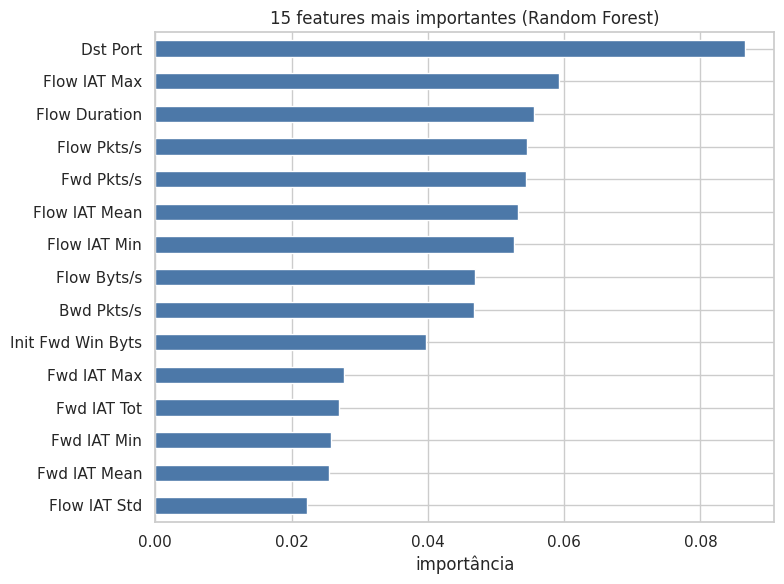

,0
Dst Port,0.086467
Flow IAT Max,0.059251
Flow Duration,0.055498
Flow Pkts/s,0.054557
Fwd Pkts/s,0.054328
Flow IAT Mean,0.053224
Flow IAT Min,0.052647
Flow Byts/s,0.046844
Bwd Pkts/s,0.046746
Init Fwd Win Byts,0.039702


In [28]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importancias.head(15)

plt.figure(figsize=(8, 6))
top15[::-1].plot(kind='barh', color='#4C78A8')
plt.title('15 features mais importantes (Random Forest)')
plt.xlabel('importância'); plt.tight_layout(); plt.show()
top15

### Discussão
- Qual feature apareceu como a **mais importante**? Ela faz sentido do ponto de vista de redes?

  Destination Port foi a feature que apareceu no topo. Faz sentido, pois, em redes, a porta de destino identifica diretamente a aplicação/serviço afetado (ex.: porta 80/443 para web, 22 para SSH), e as janelas TCP (Win Bytes) revelam o comportamento do aperto de mão (handshake), que costuma ser alterado por ferramentas automatizadas de ataque.

- Há features ligadas a **volume, duração ou quantidade de pacotes** no topo?

  Sim. Features de volume como Flow Bytes/s, Flow Pkts/s ou contagem de pacotes Fwd/Bwd ficam sob destaque porque ataques de negação de serviço (DoS/DDoS) e varreduras de rede (PortScan) distorcem drasticamente a taxa de transmissão e o tamanho dos pacotes em comparação com navegações benignas comuns. Nesse caso, podemos notar especificamente o Flow Pkts/s e Fwd Pkts/s mais próximas ao  topo.

- **Importância ≠ causalidade.** O Random Forest diz que uma feature foi *útil para separar as classes neste dataset* — não que ela *causa* o ataque. Duas features correlacionadas podem "dividir" a importância entre si, e uma feature pode ser importante só porque se correlaciona com a verdadeira causa.

  A "importância" na árvore de decisão mede apenas a eficácia de uma variável em diminuir a impureza (Gini/Entropia) na divisão dos dados deste dataset específico. Se duas variáveis forem altamente correlacionadas (ex.: número de pacotes e total de bytes), o algoritmo pode atribuir alta importância a uma e negligenciar a outra. Ela aponta correlação útil para a separação, mas não que aquela feature é a causa primária do ataque.

- O que aconteceria se **removêssemos** as features do topo? (é o Exercício 3.)

  O desempenho da IA quase não cai. Como dados de tráfego de rede possuem alta redundância (muitas features medem variações parecidas do mesmo fluxo), o modelo passa a utilizar as features secundárias correlacionadas para manter a alta taxa de acerto.

## 8. Modelo não supervisionado — K-Means

Agora **esquecemos os rótulos** e perguntamos: os fluxos formam **grupos naturais**? O K-Means agrupa por **distância**, então duas coisas importam:
1. Precisamos **padronizar** as features (senão `Flow Bytes/s`, na casa dos milhares, domina `SYN Flag Count`, que é ~0–2).
2. Removemos `Destination Port`: como é um inteiro, a distância trataria a porta 44720 como "muito maior" que a 80, o que **não tem sentido semântico** num modelo de distância (diferente da árvore, que a usa sem problema).

In [29]:
X_clu = X.drop(columns=[c for c in ['Destination Port'] if c in X.columns])
scaler = StandardScaler().fit(X_clu)
X_scaled = scaler.transform(X_clu)
print('Matriz para clustering:', X_scaled.shape)

Matriz para clustering: (200001, 79)


### Escolhendo `k` — Elbow + Silhouette
Rodamos K-Means para vários `k` e olhamos a **inércia** (cotovelo) e o **silhouette score**. Para ficar rápido, calculamos numa **subamostra** de 5 mil fluxos.

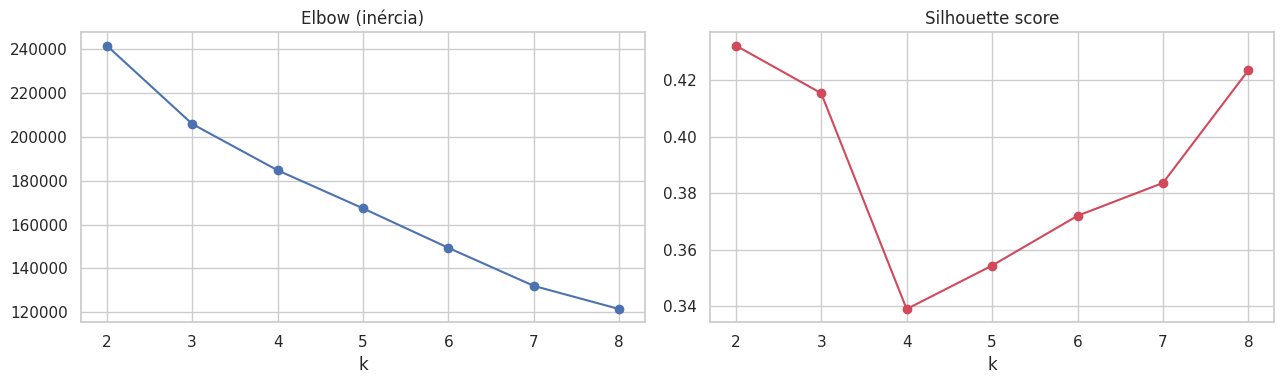

In [30]:
idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
X_sub = X_scaled[idx]

ks, inertias, sils = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit(X_sub)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_sub, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, 'o-'); ax[0].set_title('Elbow (inércia)'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sils, 'o-', color='#D1495B'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

Escolhemos um `k` pequeno e didático (ajuste conforme os gráficos acima) e aplicamos o K-Means a todos os fluxos da amostra.

In [31]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_SEED).fit(X_scaled)
df['cluster'] = kmeans.labels_

# Quantos fluxos de cada rótulo real caíram em cada cluster?
pd.crosstab(df['cluster'], df['Label'])

Label,BENIGN,Infilteration,Label
cluster,,,
0,129111,17097,1
1,9977,1107,0
2,38254,4449,0
3,5,0,0


**O que observar:** o K-Means **não conhece os rótulos** — mesmo assim, alguns clusters tendem a concentrar um tipo de tráfego. Veja se o benigno se separou e se ataques parecidos (ex.: DoS Hulk e DDoS) caíram juntos.

## 8b. Visualização com PCA
Os dados têm dezenas de dimensões. Usamos **PCA** para projetar em 2D só para **visualizar** — comparando lado a lado os clusters do K-Means e os rótulos reais.

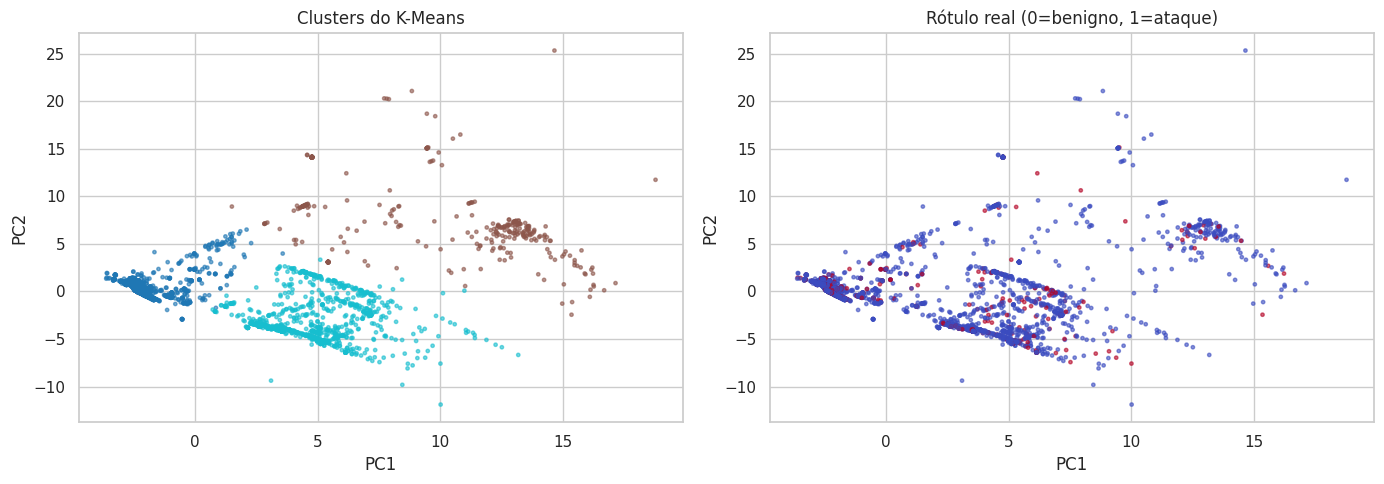

Variância explicada pelos 2 PCs: [0.234, 0.119]


In [32]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(X_scaled)

vis = np.random.choice(len(Z), size=min(6000, len(Z)), replace=False)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(Z[vis, 0], Z[vis, 1], c=df['cluster'].values[vis], cmap='tab10', s=6, alpha=0.6)
ax[0].set_title('Clusters do K-Means')

cores = pd.factorize(df['is_attack'].values)[0]
sc = ax[1].scatter(Z[vis, 0], Z[vis, 1], c=df['is_attack'].values[vis], cmap='coolwarm', s=6, alpha=0.6)
ax[1].set_title('Rótulo real (0=benigno, 1=ataque)')
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()
print('Variância explicada pelos 2 PCs:', pca.explained_variance_ratio_.round(3).tolist())

### Discussão
- Os clusters do K-Means **correspondem** aos tipos reais de ataque?

  Não de forma exata. O K-Means busca agrupar dados por proximidade geométrica no espaço de características, sem saber o que é "malicioso". Ele agrupa tráfegos com perfil estatístico semelhante, o que nem sempre coincide com a definição semântica de um ataque.

- O tráfego **benigno** ficou separado dos ataques?

  Em grande parte sim para ataques volumétricos, como DDoS e DoS, pois esses criam "extremos" no espaço de features. Porém, tráfegos benignos atípicos, como downloads grandes, acabam agrupados no mesmo cluster de ataques volumétricos, enquanto ataques discretos se misturam ao tráfego normal.

- Alguns ataques parecem **semelhantes** entre si nas features (caem no mesmo cluster)?

  Sim. Ataques que utilizam a mesma mecânica de rede acabam caindo no mesmo cluster por compartilharem padrões idênticos de tamanhos de pacote e flags TCP.

- Por que o clustering **não reproduz perfeitamente** os rótulos? (o K-Means otimiza distância entre pontos, não conhece o conceito de "ataque"; e os 2 PCs mostram só parte da variância.)

  Porque o K-Means é não supervisionado. Além disso, ele trata todas as features padronizadas com o mesmo peso e assume clusters em formato esférico, enquanto os ataques reais costumam mimetizar conexões legítimas ou se espalhar de forma não esférica.

## 9. Supervisionado vs. não supervisionado

| Abordagem     | Usa rótulos? | Objetivo          | Exemplo aqui                 |
| ------------- | ------------ | ----------------- | ---------------------------- |
| Random Forest | Sim          | Classificar       | Benigno vs. Ataque           |
| K-Means       | Não          | Encontrar grupos  | Agrupar padrões de tráfego   |

**Quando usar cada um, na prática:**
- **Supervisionado** quando você **tem rótulos confiáveis** de ataques passados e quer detectar os **conhecidos** com alta precisão.
- **Não supervisionado** quando **faltam rótulos** ou você quer descobrir **comportamento novo/anômalo** — útil para ataques que ainda não foram vistos (retomamos isso na aula 6, com detecção de anomalias).

## 10. Exercícios

**1 — EDA:** escolha **três features** e investigue como seus valores diferem entre tráfego benigno e ataques (use boxplots ou `groupby('Label').describe()`).

Flow Duration, Total Fwd Packets e Average Packet Size foram as features utilizadas. Ao comparar seus valores, é possível observar diferenças nas distribuições, principalmente em Total Fwd Packets, onde algumas classes de ataque apresentam uma quantidade de pacotes diferente do tráfego benigno.

**2 — Random Forest:** treine de novo usando um **subconjunto diferente de features** (por exemplo, só as relacionadas a pacotes) e compare as métricas.

O desempenho do modelo sofreu uma queda drástica ao utilizar apenas as 26 características relacionadas a pacotes, fazendo o Macro F1 despencar para 0,5047 e o F1-Score da classe de ataques cair para 0,16. Isso acontece porque métricas isoladas dos pacotes não carregam o contexto completo do fluxo, deixando de fora fatores determinantes como a porta de destino e as variáveis de tempo. Portanto, o experimento mostra que características puras de pacotes não possuem sinal suficiente para que a árvore de decisão distingua conexões benignas de atividades maliciosas.

**3 — Feature Importance:** **remova as 5 features mais importantes** e treine de novo. O desempenho cai muito? O que isso diz sobre redundância entre features?

A remoção das cinco características mais importantes provocou um colapso na capacidade preditiva do Random Forest, reduzindo o Macro F1 para 0,5189 e fazendo a precisão para ataques cair para 14%. Ao contrário de cenários onde há alta redundância entre as colunas, as 74 variáveis restantes no dataset não conseguiram suprir a falta dos dados de tempo, taxa de envio e porta de destino. Isso demonstra que esse grupo de cinco atributos concentrava a informação verdadeiramente vital e insubstituível para a classificação das ameaças.

**4 — Clustering:** teste **outros valores de `k`** no K-Means e compare pelo **silhouette score**. Qual `k` parece melhor?

Após testar os valores de k variando de 2 a 8, os resultados do Silhouette Score apontaram que o melhor agrupamento ocorre com k=2, que obteve a pontuação mais alta (0.4331). O valor k=3 também apresentou um bom resultado (0.4212), mas a partir de k=4 a qualidade da separação geométrica cai consideravelmente (0.3599). No contexto deste dataset de cibersegurança, faz total sentido estatístico que k=2 seja o ideal, pois o algoritmo acaba dividindo os dados na sua dicotomia mais natural e extrema: de um lado, o volume massivo de tráfego benigno e conexões comuns; do outro, os picos de anomalias volumétricas gerados pelos ataques.

**5 — Investigação:** compare (com `pd.crosstab`) os **clusters** com os **rótulos reais** e discuta por que eles são — ou não — parecidos.

Ao analisar a tabela cruzada (crosstab), notamos que os clusters gerados não correspondem perfeitamente aos rótulos reais. A distribuição mostra que, embora alguns clusters consigam isolar certas categorias volumétricas (como ataques DoS e DDoS), há uma mistura considerável, onde fluxos benignos e ataques acabam caindo no mesmo agrupamento.  Isso acontece porque o K-Means agrupa os dados puramente por similaridade estatística (distância matemática entre características como volume de pacotes, duração e taxas de bytes), sem conhecer a "intenção" daquela conexão. Ou seja, ataques distintos que utilizam mecânicas de rede parecidas caem no mesmo cluster. Da mesma forma, um tráfego benigno muito pesado (como um grande download) pode ter uma assinatura estatística parecida com um ataque de negação de serviço aos "olhos" do K-Means, fazendo com que sejam agrupados juntos, já que o modelo ignora o conceito semântico do que é ou não uma ameaça.  

In [33]:
# EXERCÍCIO 2
cols_pacotes = [c for c in X.columns if 'Pkt' in c or 'Packet' in c]
print(f"Número de features de pacotes selecionadas: {len(cols_pacotes)}")

X_train_ex2, X_test_ex2, y_train_ex2, y_test_ex2 = train_test_split(
    X[cols_pacotes], y, test_size=0.3, stratify=y, random_state=RANDOM_SEED
)

rf_pacotes = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED)
rf_pacotes.fit(X_train_ex2, y_train_ex2)
y_pred_ex2 = rf_pacotes.predict(X_test_ex2)

print("=== Desempenho do Modelo (Apenas Features de Pacotes) ===")
print(classification_report(y_test_ex2, y_pred_ex2, target_names=['Benigno', 'Ataque']))
print('Macro F1:', round(f1_score(y_test_ex2, y_pred_ex2, average='macro'), 4))

Número de features de pacotes selecionadas: 26
=== Desempenho do Modelo (Apenas Features de Pacotes) ===
              precision    recall  f1-score   support

     Benigno       0.89      0.81      0.85     53205
      Ataque       0.13      0.21      0.16      6796

    accuracy                           0.75     60001
   macro avg       0.51      0.51      0.50     60001
weighted avg       0.80      0.75      0.77     60001

Macro F1: 0.5047


In [34]:
# EXERCÍCIO 3
top5_cols = top15.head(5).index.tolist()
print("Top 5 features que serão removidas:", top5_cols)

X_sem_top5 = X.drop(columns=top5_cols)

X_train_ex3, X_test_ex3, y_train_ex3, y_test_ex3 = train_test_split(
    X_sem_top5, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED
)

rf_sem_top5 = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED)
rf_sem_top5.fit(X_train_ex3, y_train_ex3)
y_pred_ex3 = rf_sem_top5.predict(X_test_ex3)

print("=== Desempenho SEM as Top 5 Features ===")
print(classification_report(y_test_ex3, y_pred_ex3, target_names=['Benigno', 'Ataque']))
print('Macro F1:', round(f1_score(y_test_ex3, y_pred_ex3, average='macro'), 4))

Top 5 features que serão removidas: ['Dst Port', 'Flow IAT Max', 'Flow Duration', 'Flow Pkts/s', 'Fwd Pkts/s']
=== Desempenho SEM as Top 5 Features ===
              precision    recall  f1-score   support

     Benigno       0.89      0.88      0.88     53205
      Ataque       0.14      0.16      0.15      6796

    accuracy                           0.80     60001
   macro avg       0.52      0.52      0.52     60001
weighted avg       0.81      0.80      0.80     60001

Macro F1: 0.5189


In [35]:
# EXERCÍCIO 4
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

X_clu = X.drop(columns=['Destination Port'], errors='ignore')
X_scaled = StandardScaler().fit_transform(X_clu)
idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
X_sub = X_scaled[idx]
ks_test = range(2, 9)
sils_ex4 = []

print("=== Avaliação do K-Means (Silhouette Score) ===")
for k in ks_test:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit(X_sub)
    score = silhouette_score(X_sub, km.labels_)
    sils_ex4.append(score)
    print(f"k={k} | Silhouette Score: {score:.4f}")

best_k = ks_test[np.argmax(sils_ex4)]
print(f"\n>> O melhor k baseado no Silhouette Score é: {best_k}")

=== Avaliação do K-Means (Silhouette Score) ===
k=2 | Silhouette Score: 0.4331
k=3 | Silhouette Score: 0.4212
k=4 | Silhouette Score: 0.3599
k=5 | Silhouette Score: 0.3742
k=6 | Silhouette Score: 0.3865
k=7 | Silhouette Score: 0.4006
k=8 | Silhouette Score: 0.3982

>> O melhor k baseado no Silhouette Score é: 2


In [36]:
# EXERCÍCIO 5
ctab = pd.crosstab(df['cluster'], df['Label'])
display(ctab)

Label,BENIGN,Infilteration,Label
cluster,,,
0,129111,17097,1
1,9977,1107,0
2,38254,4449,0
3,5,0,0


## Checklist do entregável de hoje

- [x] Dataset carregado e limpo (duplicatas, NaN e infinitos tratados)
- [x] EDA feita (distribuição de classes e features)
- [x] Random Forest treinado e avaliado (matriz de confusão + métricas)
- [x] Feature importance interpretada
- [x] K-Means aplicado e comparado aos rótulos (crosstab + PCA)
- [x] Respostas das discussões e dos exercícios registradas no notebook

**Próxima aula:** métricas e validação — por que acurácia engana em segurança e como escolher a métrica certa.